## Skeleton-Transformer v4 — Feature Fix (No Re-Extraction)

Uses existing `../M4B_skeleton_clips_v3_fixed` data.

**Why v3-fixed (F1=0.479) was worse than v2 (F1=0.579):**

The crop-then-pose extraction normalizes keypoints relative to each person's bounding box crop (0-1 within the crop). This means a person at the LEFT of the frame and a person at the RIGHT both have their nose at x≈0.5 — because it's the center of their own crop. The inter-person distance features (centroid distance, min joint distance, hand-to-head proximity) become meaningless because both people's coordinates are in their own private coordinate space, not a shared frame space.

**What v4 fixes:**

1. **Remove broken inter-person features** — the 3 distance features that require shared coordinates are removed since they're computed from incompatible coordinate spaces.

2. **Add motion energy features** — replace inter-person distances with per-person motion magnitude features that work in any coordinate space: total velocity magnitude, max joint velocity, acceleration energy, and movement variance. These capture HOW MUCH a person moves regardless of where they are in the frame.

3. **Add pose shape features** — body aspect ratio (shoulder width / torso height), symmetry score (left vs right limb positions), and upper-body compactness. These describe the person's POSE SHAPE within the crop, which is valid in crop-relative coordinates.

4. **Better v2 data comparison** — also trains on the original v2 data with the same improved features to isolate whether crop-then-pose actually helps when features are fixed.

In [2]:
import os, cv2, gc, random, time, sys, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
import matplotlib.pyplot as plt

# Data paths
SKEL_V3_FIXED = r'../M4B_skeleton_clips_v3_fixed'   # crop-then-pose balanced
SKEL_V2       = r'../M4B_skeleton_clips_v2'          # full-frame pose (for comparison)

TARGET_CLASSES   = ['Violence', 'Threat', 'Normal']
SKEL_CLIP_FRAMES = 16
MAX_PERSONS      = 2
N_KEYPOINTS      = 17

EPOCHS        = 100
BATCH         = 32
LR_HEAD       = 1e-3
LR_FULL       = 5e-5
FREEZE_EPOCHS = 10
PATIENCE      = 25
EMA_DECAY     = 0.998
MIXUP_ALPHA   = 0.3
SAVE_DIR      = r'runs/M4B_classifier/TransformerV4'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Check both datasets exist
for name, path in [('v3-fixed (crop-then-pose)', SKEL_V3_FIXED), ('v2 (full-frame)', SKEL_V2)]:
    total = 0
    for split in ['train', 'val']:
        for cls in TARGET_CLASSES:
            d = Path(path) / split / cls
            if d.exists():
                total += len(list(d.glob('*.npy')))
    status = '✅' if total > 0 else '❌ not found'
    print(f'  {name}: {total:,} clips {status}')


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  v3-fixed (crop-then-pose): 11,000 clips ✅
  v2 (full-frame): 14,000 clips ✅


### Fixed feature engineering

The key change: inter-person distances (broken in crop-relative coords) are replaced with per-person motion descriptors and pose shape features that work correctly in any coordinate space.

In [3]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),(11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_pose_shape(kps):
    """
    Pose shape features that work in crop-relative coordinates.
    These describe the SHAPE of the body, not its absolute position.
    """
    conf = kps[:, 2]
    
    # Shoulder width / torso height ratio
    shoulder_w = abs(kps[5,0] - kps[6,0]) if conf[5]>0.2 and conf[6]>0.2 else 0.0
    hip_w = abs(kps[11,0] - kps[12,0]) if conf[11]>0.2 and conf[12]>0.2 else 0.0
    torso_h = abs((kps[5,1]+kps[6,1])/2 - (kps[11,1]+kps[12,1])/2) if all(conf[[5,6,11,12]]>0.2) else 0.0
    aspect = shoulder_w / (torso_h + 1e-6)
    
    # Left-right symmetry (lower = more asymmetric = action pose)
    sym_arms = abs(np.linalg.norm(kps[7,:2]-kps[5,:2]) - np.linalg.norm(kps[8,:2]-kps[6,:2]))
    sym_legs = abs(np.linalg.norm(kps[13,:2]-kps[11,:2]) - np.linalg.norm(kps[14,:2]-kps[12,:2]))
    
    # Upper body compactness (how spread out are the arms)
    upper_joints = [5,6,7,8,9,10]  # shoulders, elbows, wrists
    valid_upper = [j for j in upper_joints if conf[j] > 0.2]
    if len(valid_upper) >= 3:
        positions = kps[valid_upper, :2]
        compactness = positions.std()
    else:
        compactness = 0.0
    
    # Head-to-hip vertical ratio (bending/crouching indicator)
    if conf[0] > 0.2 and conf[11] > 0.2 and conf[12] > 0.2:
        head_y = kps[0, 1]
        hip_y = (kps[11,1] + kps[12,1]) / 2
        crouch = abs(head_y - hip_y)
    else:
        crouch = 0.0
    
    return np.array([aspect, shoulder_w, hip_w, torso_h,
                     sym_arms, sym_legs, compactness, crouch], dtype=np.float32)


class V4SkeletonDataset(Dataset):
    """
    Fixed feature engineering for crop-relative skeleton data.
    
    Per person per frame:
      34 (position × conf_weight) + 17 (confidence) + 16 (bones) + 5 (angles) + 8 (pose shape) = 80
    × 2 persons = 160
    + velocity/acceleration: 34×2 persons × 2 (vel+acc) = 136
    + motion energy: 4 per person × 2 = 8
    Total: ~304 features per frame
    
    NO inter-person distance features (broken in crop-relative coords).
    """
    def __init__(self, root, split, classes, augment=False, feat_mean=None, feat_std=None):
        self.samples = []
        self.augment = augment
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if d.exists():
                for p in d.glob('*.npy'):
                    self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def _mask_low_conf(self, clip):
        for p in range(MAX_PERSONS):
            valid = clip[:, p, :, 2] > 0.2
            for j in range(N_KEYPOINTS):
                if valid[:, j].sum() > 0:
                    mp = clip[valid[:, j], p, j, :2].mean(0)
                else:
                    mp = np.array([0.5, 0.5])
                for t in range(clip.shape[0]):
                    if not valid[t, j]:
                        clip[t, p, j, :2] = mp
                        clip[t, p, j, 2] = 0.0
        return clip

    def _build(self, clip):
        T = clip.shape[0]
        clip = self._mask_low_conf(clip)

        # Phase 1: Per-frame static features
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                conf = k[:, 2]
                pos_w = k[:, :2] * conf[:, None]  # conf-weighted positions
                f.extend([
                    pos_w.flatten(),       # 34
                    conf,                  # 17
                    compute_bones(k),      # 16
                    compute_angles(k),     # 5
                    compute_pose_shape(k), # 8  ← NEW
                ])
            # NO inter-person features (broken in crop coords)
            rows.append(np.concatenate(f))

        feat = np.stack(rows)  # (T, base_dim)

        # Phase 2: Velocity + acceleration
        psize = 34 + 17 + 16 + 5 + 8  # 80 per person
        all_vel = []
        all_acc = []
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]
            vel = np.zeros_like(pos)
            vel[1:] = pos[1:] - pos[:-1]
            acc = np.zeros_like(vel)
            acc[2:] = vel[2:] - vel[1:-1]
            all_vel.append(vel)
            all_acc.append(acc)

        feat = np.concatenate([feat] + all_vel + all_acc, axis=1)

        # Phase 3: Motion energy features (per-person, per-frame)
        motion_feats = []
        for t in range(T):
            mf = []
            for p in range(MAX_PERSONS):
                vel = all_vel[p][t]  # (34,) = 17 joints × 2
                acc = all_acc[p][t]

                # Reshape to (17, 2) for per-joint magnitude
                vel_2d = vel.reshape(17, 2)
                acc_2d = acc.reshape(17, 2)

                vel_mag = np.linalg.norm(vel_2d, axis=1)  # (17,) per-joint speed
                acc_mag = np.linalg.norm(acc_2d, axis=1)

                total_vel = vel_mag.sum()          # total body movement
                max_vel = vel_mag.max()             # fastest joint (punch indicator)
                acc_energy = (acc_mag**2).sum()     # total acceleration energy
                vel_variance = vel_mag.var()        # movement uniformity

                mf.extend([total_vel, max_vel, acc_energy, vel_variance])
            motion_feats.append(np.array(mf, dtype=np.float32))

        motion_feat = np.stack(motion_feats)  # (T, 8)
        feat = np.concatenate([feat, motion_feat], axis=1)

        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)
        feat = self._build(clip)
        if self.feat_mean is not None:
            feat = (feat - self.feat_mean) / (self.feat_std + 1e-8)
        return torch.tensor(feat, dtype=torch.float32), label

# Compute stats for v3-fixed data
print('Computing feature statistics (v3-fixed data with v4 features)...')
tmp = V4SkeletonDataset(SKEL_V3_FIXED, 'train', TARGET_CLASSES)
samps = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
af = np.concatenate(samps, axis=0)
FEAT_MEAN_V3 = af.mean(axis=0)
FEAT_STD_V3  = af.std(axis=0)
FEAT_DIM = FEAT_MEAN_V3.shape[0]
del samps, af, tmp
print(f'v4 feature dim: {FEAT_DIM} (v3 was 283)')
print(f'  Changed: removed 3 inter-person → added 8 pose_shape + 8 motion_energy')
print(f'  Net: +{FEAT_DIM - 283} features')
print('✅')


Computing feature statistics (v3-fixed data with v4 features)...
v4 feature dim: 304 (v3 was 283)
  Changed: removed 3 inter-person → added 8 pose_shape + 8 motion_energy
  Net: +21 features
✅


In [4]:
class SkeletonTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=4, dim_ff=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model), nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.3))
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(d_model, d_model//2),
            nn.GELU(), nn.Dropout(dropout*0.5), nn.Linear(d_model//2, num_classes))
    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        x = torch.cat([self.cls_token.expand(B,-1,-1), x], dim=1)
        pos = torch.cat([torch.zeros(1,1,x.shape[2],device=x.device), self.pos_embed], dim=1)
        x = self.transformer(x + pos)
        return self.head(self.norm(x[:, 0]))

class EMA:
    def __init__(self, model, decay=0.998):
        self.decay = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n] = self.decay*self.shadow[n] + (1-self.decay)*p.data
    def apply(self, model):
        bk = {}
        for n, p in model.named_parameters():
            if n in self.shadow: bk[n] = p.data.clone(); p.data = self.shadow[n].clone()
        return bk
    def restore(self, model, bk):
        for n, p in model.named_parameters():
            if n in bk: p.data = bk[n]

def skeleton_mixup(x, y, alpha=0.3):
    lam = max(np.random.beta(alpha, alpha), 0.5)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

def train_and_eval(data_root, feat_mean, feat_std, run_name):
    """Train one experiment, return results dict."""
    save_path = str(Path(SAVE_DIR) / f'{run_name}.pt')
    save_ema  = str(Path(SAVE_DIR) / f'{run_name}_ema.pt')
    Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

    train_ds = V4SkeletonDataset(data_root, 'train', TARGET_CLASSES,
                                  augment=True, feat_mean=feat_mean, feat_std=feat_std)
    val_ds   = V4SkeletonDataset(data_root, 'val', TARGET_CLASSES,
                                  augment=False, feat_mean=feat_mean, feat_std=feat_std)
    train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
    val_ld   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

    feat_dim = train_ds[0][0].shape[1]
    counts = [len(list((Path(data_root)/'train'/c).glob('*.npy'))) for c in TARGET_CLASSES]
    total = sum(counts)
    wts = torch.tensor([total/(3*c) for c in counts], dtype=torch.float).to(DEVICE)

    model = SkeletonTransformer(feat_dim).to(DEVICE)
    ema = EMA(model, EMA_DECAY)
    criterion = nn.CrossEntropyLoss(weight=wts)

    head_params = list(model.head.parameters()) + list(model.norm.parameters())
    body_params = [p for n,p in model.named_parameters() if not any(x in n for x in ['head','norm'])]
    for p in body_params: p.requires_grad = False

    optimizer = optim.AdamW(head_params, lr=LR_HEAD, weight_decay=1e-2)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)

    print(f'\n{"="*65}')
    print(f'  {run_name}')
    print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}  Features: {feat_dim}')
    print(f'  Weights: {dict(zip(TARGET_CLASSES, [round(w,2) for w in wts.tolist()]))}')
    print(f'{"="*65}')
    sys.stdout.flush()

    best_f1, best_ema_f1, pat = 0.0, 0.0, 0
    history = {'loss': [], 'f1': [], 'f1_ema': []}
    best_yt, best_yp = [], []
    t0 = time.time()

    for epoch in range(1, EPOCHS+1):
        if epoch == FREEZE_EPOCHS+1:
            print(f'  >>> UNFREEZING <<<')
            for p in body_params: p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-2)
            scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)
            ema = EMA(model, EMA_DECAY)

        model.train()
        tloss = 0.0
        for clips, labels in train_ld:
            clips, labels = clips.to(DEVICE), labels.to(DEVICE)
            if epoch > FREEZE_EPOCHS and MIXUP_ALPHA > 0:
                cm, ya, yb, lam = skeleton_mixup(clips, labels, MIXUP_ALPHA)
                optimizer.zero_grad()
                loss = lam*criterion(model(cm),ya) + (1-lam)*criterion(model(cm),yb)
            else:
                optimizer.zero_grad()
                loss = criterion(model(clips), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ema.update(model)
            tloss += loss.item()
        tloss /= len(train_ld)
        scheduler.step()

        model.eval()
        yt, yp = [], []
        with torch.no_grad():
            for c, l in val_ld:
                yp.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
                yt.extend(l.numpy())
        vf1 = f1_score(yt, yp, average='weighted', zero_division=0)

        bk = ema.apply(model)
        yte, ype = [], []
        with torch.no_grad():
            for c, l in val_ld:
                ype.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
                yte.extend(l.numpy())
        vfe = f1_score(yte, ype, average='weighted', zero_division=0)
        ema.restore(model, bk)

        history['loss'].append(tloss); history['f1'].append(vf1); history['f1_ema'].append(vfe)

        imp = ''
        best_this = max(vf1, vfe)
        if vf1 > best_f1:
            best_f1 = vf1; pat = 0; best_yt, best_yp = yt, yp
            torch.save(model.state_dict(), save_path); imp = ' ✅'
        else: pat += 1
        if vfe > best_ema_f1:
            best_ema_f1 = vfe
            if vfe > best_f1: best_yt, best_yp = yte, ype
            bk2 = ema.apply(model); torch.save(model.state_dict(), save_ema); ema.restore(model, bk2)
            imp += ' ✅(ema)'

        stage = 'HEAD' if epoch <= FREEZE_EPOCHS else 'FULL'
        if epoch<=5 or epoch==FREEZE_EPOCHS or epoch==FREEZE_EPOCHS+1 or epoch%10==0 or imp or pat>=PATIENCE-3:
            m, s = divmod(int(time.time()-t0), 60)
            print(f'  ep {epoch:>3} [{stage}] loss={tloss:.4f} f1={vf1:.4f} ema={vfe:.4f} {m}m{s:02d}s{imp}')
            sys.stdout.flush()
        if pat >= PATIENCE and epoch > FREEZE_EPOCHS+10:
            print(f'  Early stop at epoch {epoch}'); break

    best_overall = max(best_f1, best_ema_f1)
    m, s = divmod(int(time.time()-t0), 60)
    print(f'  Done {m}m{s:02d}s — Best: {best_overall:.4f} (reg={best_f1:.4f} ema={best_ema_f1:.4f})')

    del model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

    return {'name': run_name, 'best_f1': best_overall, 'history': history,
            'y_true': best_yt, 'y_pred': best_yp, 'elapsed': time.time()-t0}

print(f'Model params: {sum(p.numel() for p in SkeletonTransformer(FEAT_DIM).parameters()):,}')


Model params: 580,099


C:\Users\jingy\AppData\Local\Temp\ipykernel_25548\168526682.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


### Run experiments

Two runs on the same v3-fixed data to compare v3 features (with broken inter-person) vs v4 features (with pose shape + motion energy).

In [5]:
# Compute v2 stats if v2 data exists
v2_available = Path(SKEL_V2).exists() and len(list((Path(SKEL_V2)/'train'/'Violence').glob('*.npy'))) > 0

results = []

# Run 1: v3-fixed data with v4 features
print('\n' + '='*70)
print('  EXPERIMENT: v3-fixed data + v4 features (fixed)')
print('='*70)
r1 = train_and_eval(SKEL_V3_FIXED, FEAT_MEAN_V3, FEAT_STD_V3, 'v3fixed_v4feat')
results.append(r1)

# Run 2: v2 data with v4 features (if available)
if v2_available:
    print('\nComputing v2 stats with v4 features...')
    tmp = V4SkeletonDataset(SKEL_V2, 'train', TARGET_CLASSES)
    samps = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
    af = np.concatenate(samps, axis=0)
    FEAT_MEAN_V2 = af.mean(axis=0)
    FEAT_STD_V2  = af.std(axis=0)
    del samps, af, tmp
    print(f'  v2 feature dim: {FEAT_MEAN_V2.shape[0]}')

    print('\n' + '='*70)
    print('  EXPERIMENT: v2 data + v4 features (comparison)')
    print('='*70)
    r2 = train_and_eval(SKEL_V2, FEAT_MEAN_V2, FEAT_STD_V2, 'v2data_v4feat')
    results.append(r2)
else:
    print('\nv2 data not available — skipping comparison run')

print('\nAll experiments complete ✅')



  EXPERIMENT: v3-fixed data + v4 features (fixed)


C:\Users\jingy\AppData\Local\Temp\ipykernel_25548\168526682.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)



  v3fixed_v4feat
  Train: 8,800  Val: 2,200  Features: 304
  Weights: {'Violence': 1.22, 'Threat': 1.22, 'Normal': 0.73}
  ep   1 [HEAD] loss=1.0081 f1=0.3524 ema=0.3055 2m28s ✅ ✅(ema)
  ep   2 [HEAD] loss=0.9611 f1=0.3614 ema=0.3409 3m48s ✅ ✅(ema)
  ep   3 [HEAD] loss=0.9530 f1=0.3858 ema=0.3497 5m08s ✅ ✅(ema)
  ep   4 [HEAD] loss=0.9369 f1=0.3664 ema=0.3640 6m28s ✅(ema)
  ep   5 [HEAD] loss=0.9278 f1=0.3639 ema=0.3651 7m46s ✅(ema)
  ep   6 [HEAD] loss=0.9309 f1=0.3799 ema=0.3666 9m06s ✅(ema)
  ep   7 [HEAD] loss=0.9226 f1=0.3747 ema=0.3706 10m24s ✅(ema)
  ep   9 [HEAD] loss=0.9164 f1=0.3861 ema=0.3707 13m02s ✅ ✅(ema)
  ep  10 [HEAD] loss=0.9152 f1=0.3715 ema=0.3734 14m22s ✅(ema)
  >>> UNFREEZING <<<
  ep  11 [FULL] loss=1.0015 f1=0.3542 ema=0.3700 15m49s
  ep  20 [FULL] loss=0.9209 f1=0.3269 ema=0.3324 28m54s
  ep  30 [FULL] loss=0.9063 f1=0.3308 ema=0.3410 43m30s
  ep  31 [FULL] loss=0.9015 f1=0.3408 ema=0.3367 44m58s
  ep  32 [FULL] loss=0.8947 f1=0.3383 ema=0.3363 46m26s
  ep  33

C:\Users\jingy\AppData\Local\Temp\ipykernel_25548\168526682.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  ep   1 [HEAD] loss=0.8613 f1=0.5102 ema=0.5034 3m16s ✅ ✅(ema)
  ep   2 [HEAD] loss=0.8051 f1=0.5140 ema=0.5123 4m57s ✅ ✅(ema)
  ep   3 [HEAD] loss=0.7737 f1=0.4698 ema=0.4923 6m39s
  ep   4 [HEAD] loss=0.7648 f1=0.5067 ema=0.4910 8m22s
  ep   5 [HEAD] loss=0.7573 f1=0.5199 ema=0.4939 10m04s ✅
  ep   8 [HEAD] loss=0.7382 f1=0.5251 ema=0.4881 15m11s ✅
  ep  10 [HEAD] loss=0.7336 f1=0.4816 ema=0.4831 18m36s
  >>> UNFREEZING <<<
  ep  11 [FULL] loss=0.9074 f1=0.4725 ema=0.4699 20m28s
  ep  20 [FULL] loss=0.8009 f1=0.4384 ema=0.4363 37m17s
  ep  30 [FULL] loss=0.7880 f1=0.4424 ema=0.4294 56m01s
  ep  31 [FULL] loss=0.8024 f1=0.4482 ema=0.4310 57m54s
  ep  32 [FULL] loss=0.7702 f1=0.4545 ema=0.4280 59m46s
  ep  33 [FULL] loss=0.7819 f1=0.4122 ema=0.4262 61m39s
  Early stop at epoch 33
  Done 61m39s — Best: 0.5251 (reg=0.5251 ema=0.5123)

All experiments complete ✅


  V4 FEATURE FIX RESULTS
  Run                                           F1   VioR   ThrR   NorR
  ----------------------------------------------------------------------
  CNN+LSTM v3 (deployed)                     0.638   0.57   0.26   0.92
  Skeleton-Transformer B (v2, best prev)     0.579   0.73   0.55   0.48
  v3-fixed (broken inter-person feat)        0.479   0.44   0.55   0.45
  ----------------------------------------------------------------------
  v3fixed_v4feat                             0.386   0.34   0.64   0.28 ← NEW
  v2data_v4feat                              0.525   0.63   0.61   0.39 ← NEW

Best run: v2data_v4feat (F1=0.5251)
              precision    recall  f1-score   support

    Violence       0.42      0.63      0.51       800
      Threat       0.46      0.61      0.53       800
      Normal       0.85      0.39      0.54      1200

    accuracy                           0.52      2800
   macro avg       0.58      0.54      0.52      2800
weighted avg       0.6

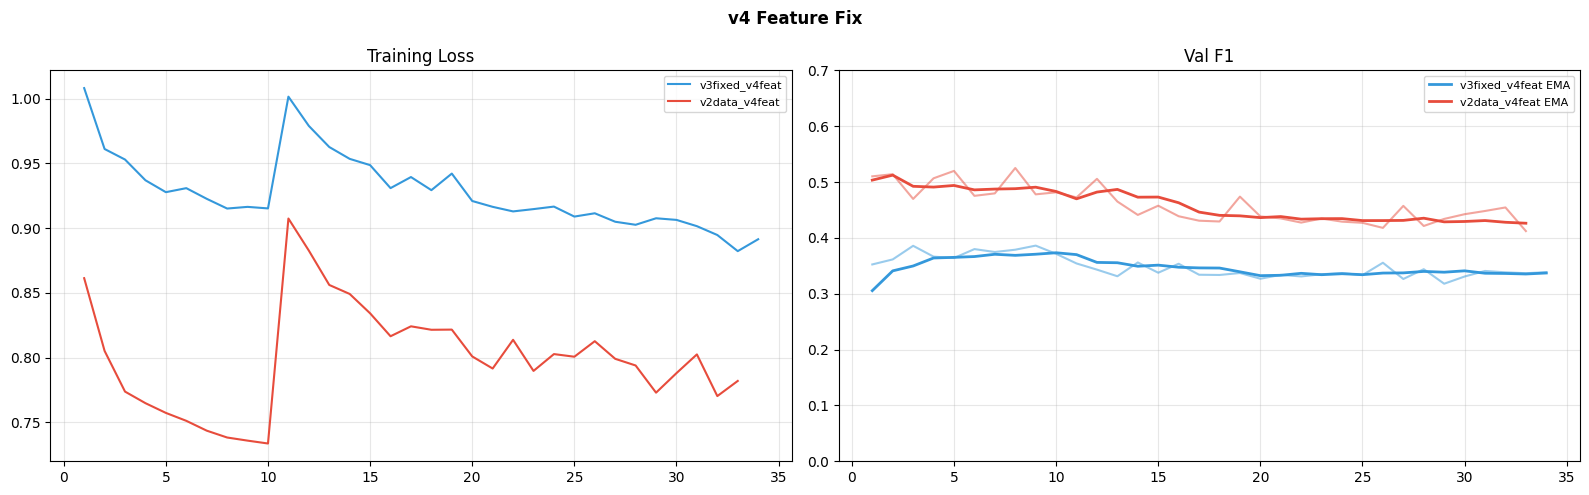

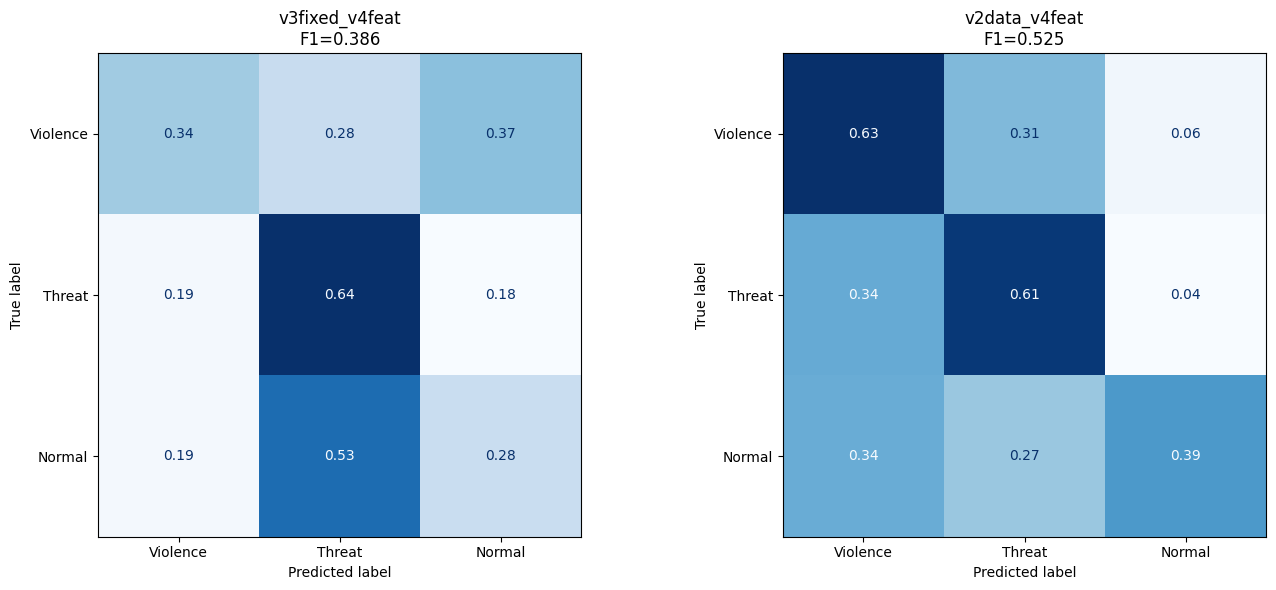


📈 Improved over v3-fixed: 0.479 → 0.525
   Feature fix helped! Prev skeleton best: 0.579

Best weights: runs/M4B_classifier/TransformerV4/


In [6]:
# Results
print('='*95)
print('  V4 FEATURE FIX RESULTS')
print('='*95)
print(f'  {"Run":<40} {"F1":>7} {"VioR":>6} {"ThrR":>6} {"NorR":>6}')
print('  ' + '-'*70)

# Reference rows
refs = [
    ('CNN+LSTM v3 (deployed)',                 0.638, 0.57, 0.26, 0.92),
    ('Skeleton-Transformer B (v2, best prev)', 0.579, 0.73, 0.55, 0.48),
    ('v3-fixed (broken inter-person feat)',     0.479, 0.44, 0.55, 0.45),
]
for name, f, vr, tr, nr in refs:
    print(f'  {name:<40} {f:>7.3f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f}')
print('  ' + '-'*70)

for r in results:
    yt, yp = np.array(r['y_true']), np.array(r['y_pred'])
    acc = accuracy_score(yt, yp)
    vr = get_m(yt, yp, 'Violence')
    tr = get_m(yt, yp, 'Threat')
    nr = get_m(yt, yp, 'Normal')
    marker = ' ← NEW'
    print(f'  {r["name"]:<40} {r["best_f1"]:>7.3f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f}{marker}')

print('='*95)

# Per-class for best run
best_r = max(results, key=lambda r: r['best_f1'])
print(f'\nBest run: {best_r["name"]} (F1={best_r["best_f1"]:.4f})')
print(classification_report(np.array(best_r['y_true']), np.array(best_r['y_pred']),
      target_names=TARGET_CLASSES, zero_division=0))

# Training curves
colors = ['#3498DB', '#E74C3C', '#2ECC71']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for r, c in zip(results, colors):
    ex = range(1, len(r['history']['f1'])+1)
    axes[0].plot(ex, r['history']['loss'], '-', color=c, linewidth=1.5, label=r['name'])
    axes[1].plot(ex, r['history']['f1'], '-', color=c, linewidth=1.5, alpha=0.5)
    axes[1].plot(ex, r['history']['f1_ema'], '-', color=c, linewidth=2, label=f'{r["name"]} EMA')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[1].set_title('Val F1'); axes[1].set_ylim(0, 0.7); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.suptitle('v4 Feature Fix', fontweight='bold')
plt.tight_layout(); plt.show()

# Confusion matrix
fig, axes = plt.subplots(1, len(results), figsize=(7*len(results), 6))
if len(results) == 1: axes = [axes]
for ax, r in zip(axes, results):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{r["name"]}\nF1={r["best_f1"]:.3f}')
plt.tight_layout(); plt.show()

# Verdict
best_f1 = best_r['best_f1']
print()
if best_f1 > 0.638:
    print(f'🏆 BEATS CNN+LSTM v3! ({best_f1:.3f} vs 0.638)')
elif best_f1 > 0.579:
    print(f'🏆 New skeleton best! ({best_f1:.3f} vs prev 0.579)')
    print(f'   Gap to CNN+LSTM: {0.638-best_f1:.3f}')
elif best_f1 > 0.479:
    print(f'📈 Improved over v3-fixed: {0.479:.3f} → {best_f1:.3f}')
    print(f'   Feature fix helped! Prev skeleton best: 0.579')
else:
    print(f'📊 Result: {best_f1:.3f}')

print(f'\nBest weights: {SAVE_DIR}/')
